In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
mnist=keras.datasets.mnist
(x_train,y_train),(x_test,y_test) = mnist.load_data()
x_train,x_test=x_train / 255.0 , x_test / 255.0  #Converting to Grayscale for better training

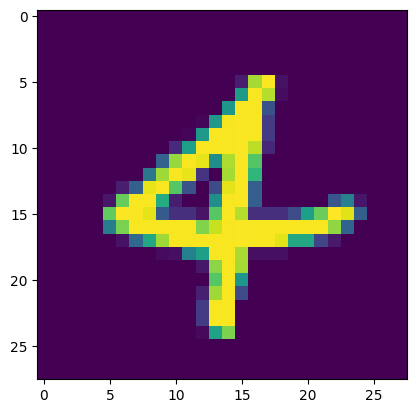

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[150])

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
model=keras.Sequential([
     keras.layers.Flatten(input_shape=(28,28,1)),
     keras.layers.Dense(128,activation='relu'),
     keras.layers.Dense(10,activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,validation_split=0.1,epochs=15)

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9207 - loss: 0.2776 - val_accuracy: 0.9660 - val_loss: 0.1259
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9639 - loss: 0.1214 - val_accuracy: 0.9727 - val_loss: 0.0923
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9753 - loss: 0.0816 - val_accuracy: 0.9760 - val_loss: 0.0837
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9812 - loss: 0.0612 - val_accuracy: 0.9770 - val_loss: 0.0793
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9849 - loss: 0.0477 - val_accuracy: 0.9798 - val_loss: 0.0773
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9881 - loss: 0.0390 - val_accuracy: 0.9785 - val_loss: 0.0721
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9916 - loss: 0.0284 - val_accuracy: 0.9773 - val_loss: 0.0854
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9921 - loss: 0.0244

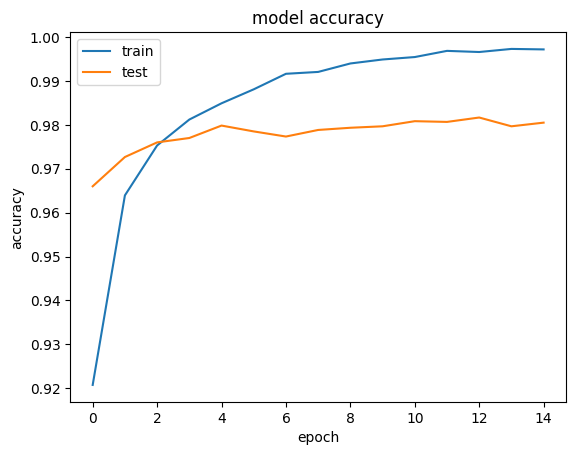

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

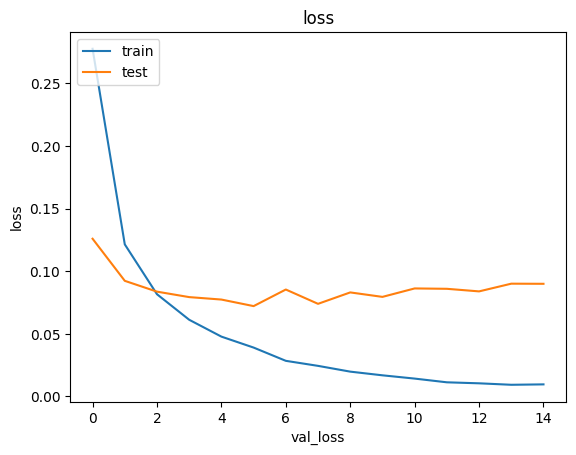

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('val_loss')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [ ]:
y_pred=model.predict(x_test)
y_pred[8888]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([2.0354358e-12, 1.0681023e-15, 4.1006688e-11, 4.1287966e-11,
       1.0488035e-10, 6.3966217e-15, 9.9999994e-01, 4.7401251e-17,
       2.1631474e-15, 6.8848212e-19], dtype=float32)

In [ ]:
import numpy as np
y_pred1=np.argmax(y_pred,axis=1)
r=y_pred1[150]

Text(0.5, 1.0, 'y_test:9 , y_pred:9')

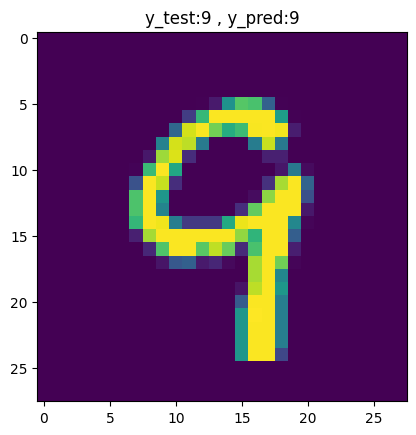

In [ ]:
plt.imshow(x_test[150])
plt.title(f"y_test:{y_test[150]} , y_pred:{y_pred1[150]}")

In [ ]:
import cv2
from google.colab import files
# Upload image
uploaded = files.upload()

# Get uploaded file name
filename = list(uploaded.keys())[0]

# Read image
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

Saving example1.jpeg to example1 (1).jpeg


In [ ]:
img1=cv2.resize(img,(28,28))
img=img-255
img1= img1 / 255.0

# Reshape for model input
img1 = img1.reshape(1,28, 28)


In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
y_pred=model.predict(img1)
y_pred3=np.argmax(y_pred[0])
y_pred3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


np.int64(7)

In [ ]:
model.save("digit_model.h5")